# Publication figures: ablation and GNN training

A **2 x 3** figure inspired by Figures 4 and 6 of *Mastering Model Fit: Applications of the InterModel Vigorish for Interpretable Machine Learning*. Columns are MNIST / CNN, UCI HAR / BiGRU, and MAGIC Gamma / MLP. Heatmaps occupy the top row; bars occupy the bottom row.

This notebook only loads completed results. It does not download data or train models, even when `run_all.sh --fresh` calls it. First complete the three source notebooks in `src/empirical/ablation_imv/` and `src/empirical/gnn/gnn_training.ipynb`. The final section plots the six GNN learning curves.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'src' / 'figure_utils.py').is_file()
)
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import imvpy
from figure_utils import (
    ABLATION_EXAMPLES, artifact_directory, figure_directory,
    load_ablation_results, plot_ablation_overview, save_publication_figure,
)

ARTIFACT_ROOT = artifact_directory()
FIGURES = figure_directory(PROJECT_ROOT)
FIGURE_NAME = 'ablation_imv__mnist_har_magic_gamma__overview'
print(f'imvpy {imvpy.__version__}')
print(f'Results: {ARTIFACT_ROOT}')
print(f'Figures: {FIGURES}')

imvpy 1.2.0
Results: /home/jinx/.cache/imv/notebook_artifacts
Figures: /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures


## What the panels measure

- **Heatmaps:** the mean of the saved seed-level ablation matrices. Rows are enhanced models; columns are basic models. Positive values favour the row. The current `imvpy` matrices are directional: opposite cells need not be negatives of one another. We preserve these values rather than mirror a triangle as in the paper's displayed matrices. All panels share one colour scale centred on zero.
- **Bars:** each full or ablated model versus the paper's **constant 0.5-probability baseline** (Section 4.4, Eq. 10). `imvpy.imv_from_likelihoods(0.5, likelihood)` transforms each saved seed-level geometric mean likelihood **before** taking the mean. These are not full-model-versus-ablation differences, nor accuracy scores.
- **Uncertainty:** whiskers are sample standard deviations (`ddof=1`) across seeds 42-51, not confidence intervals. Both rows retain the source notebook's variant order, with the full model first.

The baseline follows the paper even for an imbalanced task; it is not a prevalence-fitted null. MAGIC Gamma removes feature groups with a fixed MLP architecture; MNIST and HAR remove architectural components. No assumption is made that every ablation must reduce performance.

The loader requires all ten seeds and every variant/pair, rejects duplicate or non-finite results, and cross-checks pairwise IMVs against the likelihood diagnostics through `imvpy`. Incomplete or inconsistent source files fail with an actionable error.

In [2]:
results = [load_ablation_results(example, ARTIFACT_ROOT) for example in ABLATION_EXAMPLES]
pd.DataFrame([
    {
        'example': result.example.title,
        'source_notebook': f'src/empirical/ablation_imv/{result.example.notebook_stem}.ipynb',
        'seeds': len(result.seeds),
        'variants': len(result.example.variants),
        'result_files': ', '.join(path.name for path in result.source_paths),
    }
    for result in results
])

,example,source_notebook,seeds,variants,result_files
0,MNIST / CNN,src/empirical/ablation_imv/ablation_imv_mnist....,10,5,"mnist_ablation_imv_by_seed.csv, mnist_variant_..."
1,UCI HAR / BiGRU,src/empirical/ablation_imv/ablation_imv_har.ipynb,10,5,"har_ablation_imv_by_seed.csv, har_variant_diag..."
2,MAGIC Gamma / MLP,src/empirical/ablation_imv/ablation_imv_magic_...,10,5,"magic_gamma_ablation_imv_by_seed.csv, magic_ga..."


In [3]:
bar_summary = pd.concat(
    {result.example.dataset: result.null_summary for result in results},
    names=['example', 'variant'],
)
bar_summary.rename(columns={'mean': 'mean_imv_vs_null', 'std': 'seed_sd', 'count': 'n_seeds'})

mean_imv_vs_null   seed_sd  n_seeds
example     variant                                             
mnist       FullCNN                  0.974878  0.027631       10
            NoConv2                  0.955596  0.014775       10
            NoHidden                 0.974729  0.004644       10
            NoDropout                0.980401  0.007133       10
            Linear                   0.751424  0.079001       10
har         FullBiGRU                0.918786  0.051443       10
            UniGRU                   0.897073  0.056798       10
            OneLayer                 0.909113  0.048400       10
            NoAttention              0.929892  0.031127       10
            MeanPoolMLP              0.411342  0.025442       10
magic_gamma FullFeatures             0.815500  0.006766       10
            NoGeometry               0.775652  0.006256       10
            NoConcentration          0.758893  0.008791       10
            NoMoments                0.815057  0.005401       10
            NoOrientation            0.701259  0.010048       10

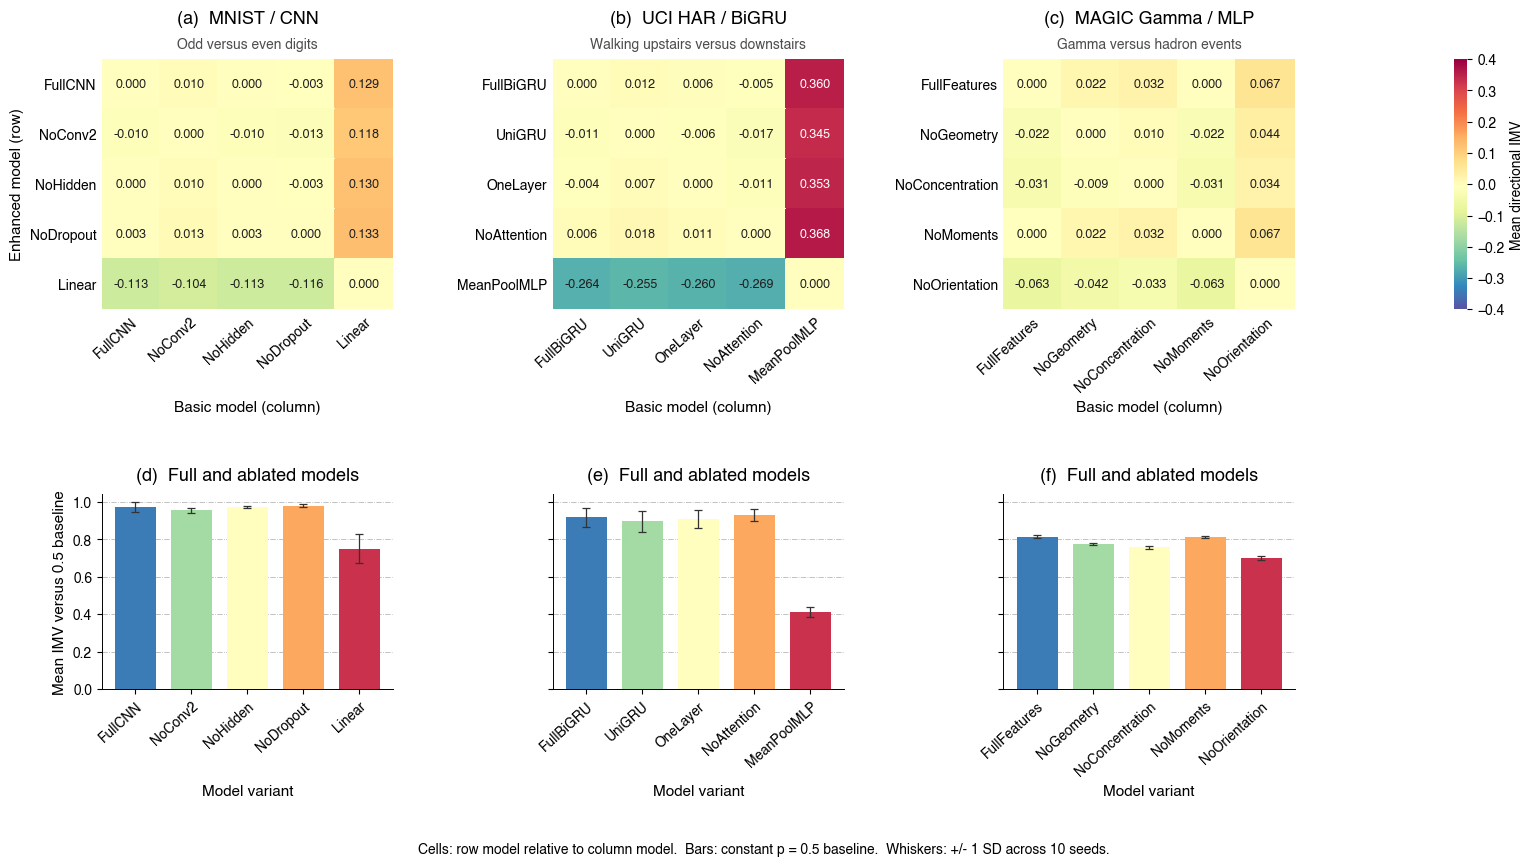

PDF: output/figures/ablation_imv__mnist_har_magic_gamma__overview.pdf


In [4]:
fig, axes = plot_ablation_overview(results)
paths = save_publication_figure(fig, FIGURES / FIGURE_NAME)
plt.show()
plt.close(fig)
for file_format, path in paths.items():
    print(f'{file_format.upper()}: {path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path}')

## Export and rerun

Exports: `output/figures/ablation_imv__mnist_har_magic_gamma__overview.pdf`. Only PDF is saved, using Helvetica, the `Spectral_r` palette, vector cells and a vector colourbar, with no embedded heatmap images. `IMV_FIGURE_DIR` overrides the destination, and `IMV_ARTIFACT_CACHE` / `IMV_CACHE_HOME` select existing results using the source notebooks' conventions.

From the repository root, rebuild only this figure with:

```bash
jupyter nbconvert --execute --to notebook --inplace src/plotter/plotter.ipynb
```

**Suggested caption.** Ablate-IMV across three binary classification examples: MNIST odd/even digits with a CNN, UCI HAR upstairs/downstairs with a bidirectional GRU, and MAGIC Gamma gamma/hadron classification with an MLP. Top: directional pairwise IMV, with enhanced models on rows and basic models on columns. Bottom: each model's IMV against constant 0.5-probability predictions. Entries and bars average ten seed-level scores; whiskers show one sample standard deviation across seeds. Each column lists the full model first. MAGIC Gamma ablates input feature groups; MNIST and HAR ablate architectural components.

## GNN training: six examples from Section 6 and Appendix F.3

The source notebook is `src/empirical/gnn/gnn_training.ipynb`. In the supplied paper, the appendix graph-training curves are Figure **A6**, not A5. The six panels match the main/appendix dataset order: PROTEINS, NCI1, NCI109, Mutagenicity, AIDS, DD.

IMV is the emphasized curve. Accuracy, precision and recall are plotted from the same held-out test predictions. Precision/recall are binary for canonical class 1 at threshold 0.5, per Appendix E.2.2. The IMV null predicts **training prevalence**, unlike the ablation figure's 0.5 null.

Lines show the mean across ten seeds. A shaded band follows the minimum and maximum seed values at every epoch along each mean curve, separately for each dataset and metric; individual seed lines are omitted from this overview. These are observed seed ranges, not confidence intervals or SD bands. Every epoch is plotted, with no smoothing or renderer path simplification; negative IMV remains visible. Undefined IMV creates a gap in both the mean and range rather than using fewer seeds. The table below reports finite-seed coverage. Ranges are calculated directly from saved metrics; the original CI description in training manifests does not control plotting.


In [5]:
from empirical.gnn.gnn_results import load_gnn_results, plot_gnn_learning_curves, plot_gnn_seed_curves

gnn = load_gnn_results(ARTIFACT_ROOT)
gnn.summary.query("split == 'test' and metric == 'imv'").groupby("dataset", sort=False).agg(
    minimum_valid_seeds=("n_valid", "min"),
    complete_epochs=("n_valid", lambda counts: int((counts == 10).sum())),
)


,minimum_valid_seeds,complete_epochs
dataset,,
PROTEINS,10,201
NCI1,10,201
NCI109,10,201
Mutagenicity,10,201
AIDS,10,201
DD,10,201


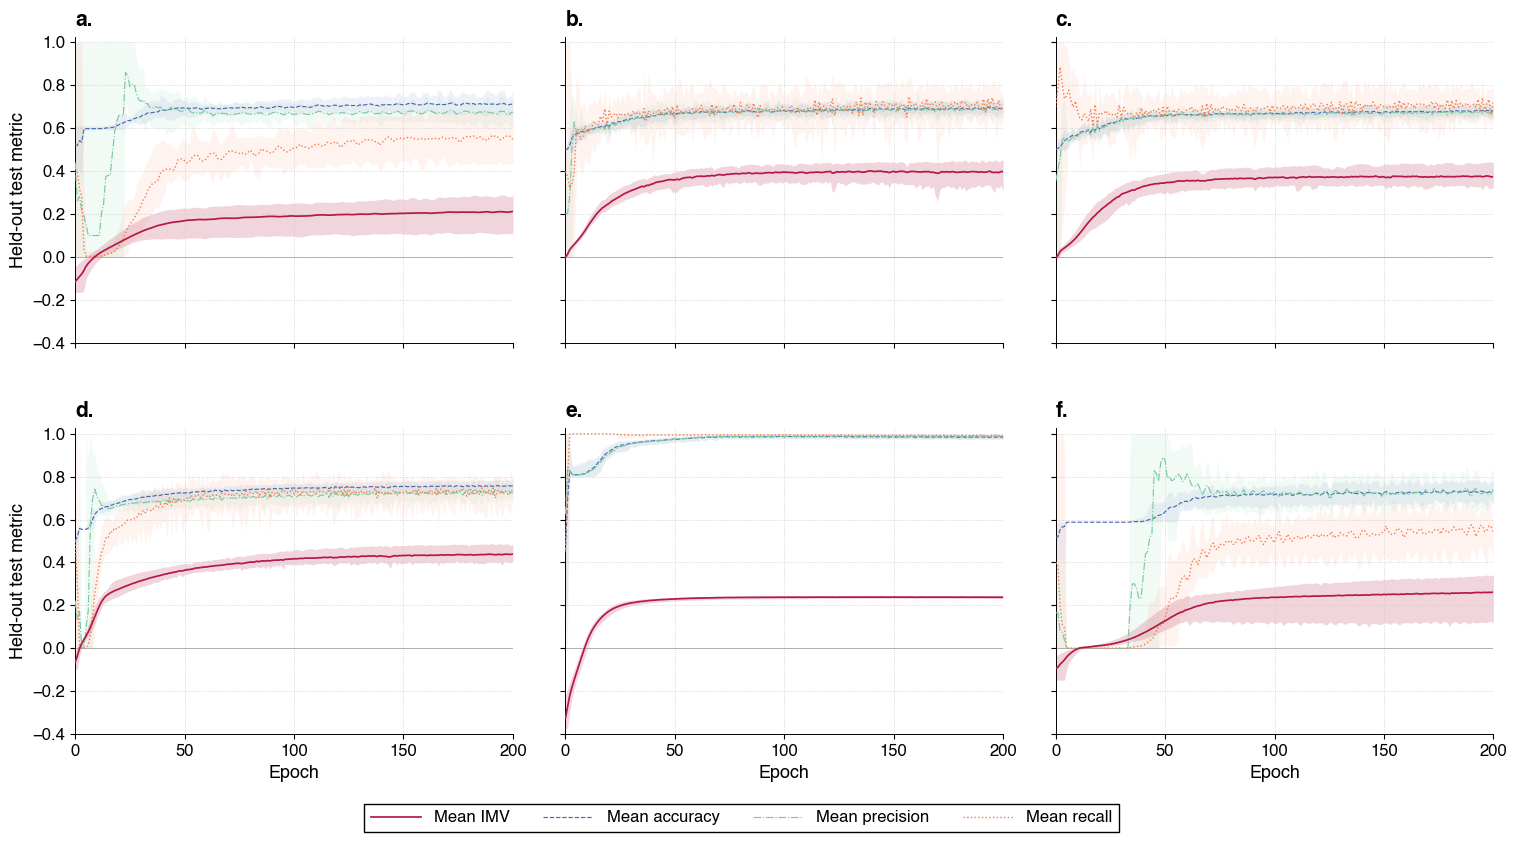

PDF: /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/gnn_training__six_datasets__learning_curves.pdf


In [6]:
gnn_fig, gnn_axes = plot_gnn_learning_curves(gnn)
gnn_paths = save_publication_figure(
    gnn_fig, FIGURES / "gnn_training__six_datasets__learning_curves"
)
plt.show()
plt.close(gnn_fig)
print("PDF:", gnn_paths["pdf"])


In [7]:
gnn.summary.query("split == 'test' and epoch == 200").pivot(
    index="dataset", columns="metric", values="mean"
).reindex(gnn.manifest["datasets"])


metric,accuracy,balanced_accuracy,brier,f1,imv,log_loss,precision,recall,roc_auc
dataset,,,,,,,,,
PROTEINS,0.711377,0.684887,0.200066,0.603413,0.212052,0.587760,0.674938,0.548310,0.734824
NCI1,0.694003,0.693989,0.204864,0.696626,0.397838,0.609488,0.692744,0.702589,0.747890
NCI109,0.684194,0.683895,0.210973,0.699340,0.374870,0.616893,0.673002,0.730128,0.732406
Mutagenicity,0.757604,0.755364,0.164066,0.729687,0.438739,0.502693,0.725695,0.734828,0.836639
AIDS,0.984000,0.973125,0.012072,0.990014,0.237739,0.054440,0.988840,0.991250,0.993840
DD,0.732203,0.703109,0.190149,0.622014,0.261581,0.568681,0.742695,0.536986,0.761301


**Suggested figure caption.** Held-out test performance during training of a three-layer graph convolutional network on six TU graph-classification benchmarks: **a.** PROTEINS (1,113 graphs), **b.** NCI1 (4,110), **c.** NCI109 (4,127), **d.** Mutagenicity (4,337), **e.** AIDS (2,000), and **f.** DD (1,178). Lines show the mean IMV, accuracy, precision, and recall across ten independent runs (seeds 42-51); shaded bands span the minimum and maximum seed values at each epoch, rather than confidence intervals. Each run uses a seed-specific stratified 70/15/15 training/validation/test split and 200 training epochs. Epoch 0 denotes the untrained model. IMV compares the model's predicted probabilities with a constant-probability null estimated from training-set prevalence. Accuracy, binary precision, and binary recall use a probability threshold of 0.5, with class 1 treated as positive. All epochs are shown without temporal smoothing or renderer path simplification, and negative IMV values are retained.

**Methods note.** This is a documented reconstruction rather than an assertion of exact numerical replication of the paper; the source training notebook distinguishes specified settings from implementation choices.


## Inspect the seed heterogeneity directly

A seed mean can hide opposing epoch-to-epoch changes even without temporal smoothing. The paper averages five seeds; this study uses the requested ten. The overview's common y-axis includes all four metrics and negative epoch-0 IMV, so small changes also occupy less vertical space than in the paper. Thick lines previously obscured small fluctuations, and Matplotlib's [default path simplification](https://matplotlib.org/3.7.3/users/explain/performance.html) was enabled. The plotter now disables simplification and uses thinner means with shaded min-max bands; individual trajectories are available only in the separate diagnostic below.

The diagnostic below draws all ten raw IMV trajectories, with **no seed averaging** and **independent, explicitly labelled y-axis ranges**. It includes every saved epoch, not just checkpoints. The following table measures absolute consecutive-epoch changes from epoch 100 to 200; it is descriptive, not a convergence test or smoothing operation. No seeds are chosen based on their appearance. Undefined values propagate rather than being discarded.

The remaining numerical differences from the paper cannot be attributed precisely without its original GNN code: hidden width, optimizer, pooling, dropout, feature handling, exact splits and the Section 6 null were not all specified. Those reconstruction choices remain fixed; they are not adjusted to manufacture fluctuations. Use `plot_gnn_seed_curves(gnn, metric='accuracy')` (or `precision` / `recall`) to inspect the other metrics in the same format.

**Suggested diagnostic figure caption.** Individual-seed IMV trajectories on **a.** PROTEINS, **b.** NCI1, **c.** NCI109, **d.** Mutagenicity, **e.** AIDS, and **f.** DD. Each coloured line represents one of ten independent runs (seeds 42-51), under the same protocol as the mean-and-range figure. All 201 evaluated epochs, including the untrained epoch 0, are shown without seed averaging, temporal smoothing, or renderer path simplification. IMV is measured against the training-prevalence null. Y-axis ranges vary across panels to expose within-run changes; numerical comparisons should use the tick labels.


In [8]:
import numpy as np

seed_variation = []
for dataset in gnn.manifest['datasets']:
    trajectories = gnn.epochs.query("dataset == @dataset and split == 'test'").pivot(
        index='epoch', columns='seed', values='imv'
    ).sort_index()
    assert trajectories.shape == (201, 10)
    np.testing.assert_array_equal(trajectories.index, np.arange(201))
    values = trajectories.loc[100:200].to_numpy()
    steps = np.diff(values, axis=0)
    seed_variation.append({
        'dataset': dataset,
        'epochs_per_seed': len(trajectories),
        'mean_abs_individual_seed_step': np.abs(steps).mean(),
        'mean_abs_ten_seed_mean_step': np.abs(np.diff(values.mean(axis=1))).mean(),
        'largest_abs_individual_seed_step': np.abs(steps).max(),
    })
pd.DataFrame(seed_variation).set_index('dataset')


,epochs_per_seed,mean_abs_individual_seed_step,mean_abs_ten_seed_mean_step,largest_abs_individual_seed_step
dataset,,,,
PROTEINS,201,0.001401,0.000507,0.008555
NCI1,201,0.005500,0.001745,0.053091
NCI109,201,0.004660,0.001697,0.045315
Mutagenicity,201,0.003361,0.001157,0.030546
AIDS,201,0.000301,0.000122,0.002332
DD,201,0.002287,0.000897,0.020471


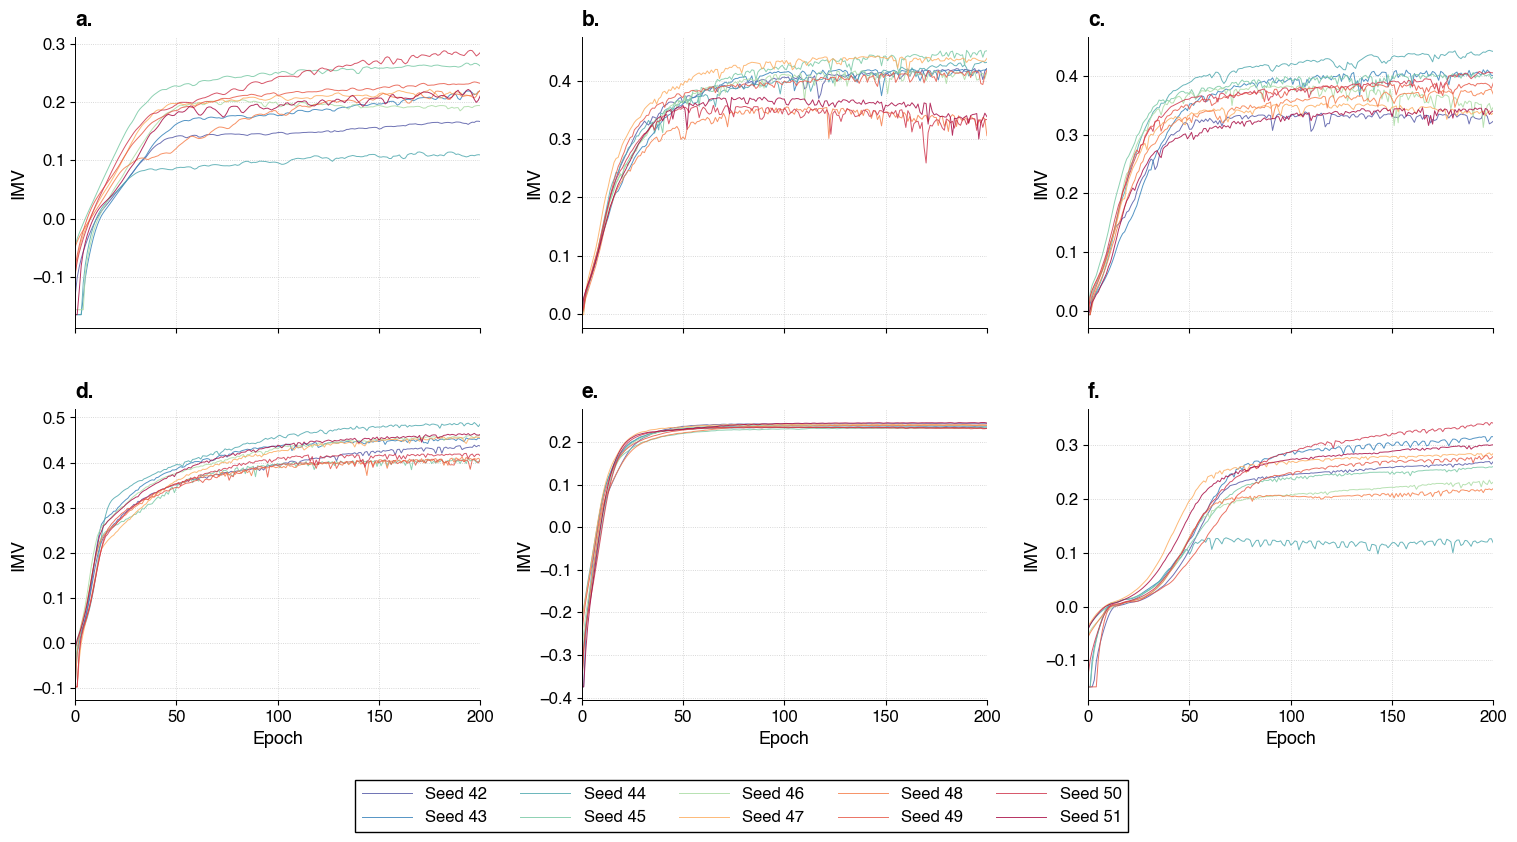

PDF: /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/gnn_training__six_datasets__individual_seed_imv.pdf


In [9]:
seed_fig, seed_axes = plot_gnn_seed_curves(gnn, metric='imv')
seed_paths = save_publication_figure(
    seed_fig, FIGURES / 'gnn_training__six_datasets__individual_seed_imv'
)
plt.show()
plt.close(seed_fig)
print('PDF:', seed_paths['pdf'])
